<a href="https://colab.research.google.com/github/dipalimhapsekar/CSL701-CE-28_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dipali Manohar Mhapsekar CE28

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Download the dataset if not already present
# This file is commonly found at the UCI Machine Learning Repository, but the direct link might change.
# Using a reliable raw GitHub link for the dataset.
!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

# Column names
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Load dataset
df = pd.read_csv(
    'pima-indians-diabetes.data.csv',
    header=None,
    names=columns
)

# Display first five records
print("First Five Records:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

--2026-09-25 05:27:54--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘pima-indians-diabetes.data.csv’

pima-indians-diabet 100%[===================>]  22.73K  --.-KB/s    in 0.001s  

2026-09-25 05:27:55 (26.7 MB/s) - ‘pima-indians-diabetes.data.csv’ saved [23278/23278]

First Five Records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23    

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class Balance:
         Count  Percentage
Outcome                   
0          500   65.104167
1          268   34.895833


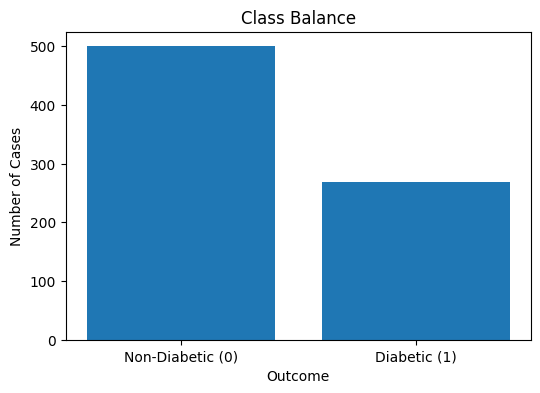

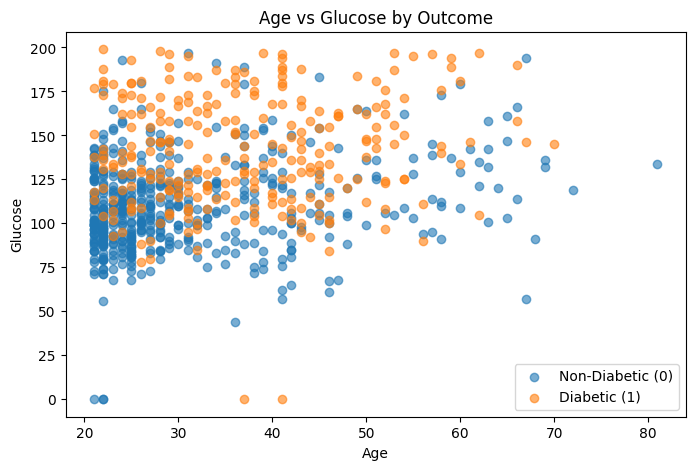

In [5]:
# Task 2: Exploratory Data Analysis (EDA)

# ---------------------------------------
# 1. Class Balance
# ---------------------------------------

# Calculate absolute count
class_count = df['Outcome'].value_counts().sort_index()

# Calculate percentage
class_percentage = df['Outcome'].value_counts(
    normalize=True
).sort_index() * 100

print("Class Counts:")
print(class_count)

print("\nClass Percentages:")
print(class_percentage)

# Display count and percentage together
class_summary = pd.DataFrame({
    'Count': class_count,
    'Percentage': class_percentage
})

print("\nClass Balance:")
print(class_summary)

# Bar chart
plt.figure(figsize=(6, 4))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    class_count.values
)

plt.xlabel('Outcome')
plt.ylabel('Number of Cases')
plt.title('Class Balance')

plt.show()


# ---------------------------------------
# 2. Age vs Glucose Scatter Plot
# ---------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df[df['Outcome'] == 0]['Age'],
    df[df['Outcome'] == 0]['Glucose'],
    label='Non-Diabetic (0)',
    alpha=0.6
)

plt.scatter(
    df[df['Outcome'] == 1]['Age'],
    df[df['Outcome'] == 1]['Glucose'],
    label='Diabetic (1)',
    alpha=0.6
)

plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Age vs Glucose by Outcome')
plt.legend()

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [6]:
# Task 3: Preprocessing and Handling Missing Values

import numpy as np
import pandas as pd

# 1. Features where 0 is physically impossible
invalid_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# 2. Display number of zero values before replacement
print("Zero values before replacement:")
for feature in invalid_features:
    print(feature, ":", (df[feature] == 0).sum())

# 3. Replace 0 values with NaN
df[invalid_features] = df[invalid_features].replace(0, np.nan)

# Display missing values after replacement
print("\nMissing values after replacing 0 with NaN:")
print(df[invalid_features].isnull().sum())

# 4. Handle missing values using median
for feature in invalid_features:
    df[feature] = df[feature].fillna(df[feature].median())

# 5. Check missing values after imputation
print("\nMissing values after median imputation:")
print(df[invalid_features].isnull().sum())

# Display first 5 records
print("\nFirst 5 records after preprocessing:")
print(df.head())

Zero values before replacement:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing 0 with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

First 5 records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [7]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# 1. Separate feature matrix X and target vector y

# First 8 columns = Features
X = df.iloc[:, :8]

# 9th column = Target
y = df.iloc[:, 8]

# Display shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

# 2. Split data into 80% training and 20% testing
# stratify=y preserves class proportions

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display train-test shapes
print("\nTraining Data:")
print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("\nTest Data:")
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

# Check class distribution
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTest Class Distribution:")
print(y_test.value_counts())

X Shape: (768, 8)
y Shape: (768,)

Training Data:
X_train Shape: (614, 8)
y_train Shape: (614,)

Test Data:
X_test Shape: (154, 8)
y_test Shape: (154,)

Training Class Distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test Class Distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [8]:
# Task 5: Custom Bootstrap Sampling

import numpy as np

# 1. Create bootstrap sampling function
def get_bootstrap_sample(X, y):

    # Number of training samples
    N = len(X)

    # Randomly select N indices with replacement
    indices = np.random.choice(N, size=N, replace=True)

    # Create bootstrap samples
    X_bootstrap = X.iloc[indices].copy()
    y_bootstrap = y.iloc[indices].copy()

    return X_bootstrap, y_bootstrap, indices


# 2. Generate one bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

# 3. Check size of bootstrap sample
print("Original Training Size:", len(X_train))
print("Bootstrap Sample Size:", len(X_bootstrap))

print("\nX_bootstrap Shape:", X_bootstrap.shape)
print("y_bootstrap Shape:", y_bootstrap.shape)


# 4. Find duplicated indices
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nDuplicated Original Indices:")
print(duplicated_indices)

print("Number of duplicated indices:", len(duplicated_indices))


# 5. Find OOB (Out-of-Bag) indices
original_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    original_indices,
    unique_indices
)

print("\nOut-of-Bag (OOB) Indices:")
print(oob_indices)

print("Number of OOB samples:", len(oob_indices))

Original Training Size: 614
Bootstrap Sample Size: 614

X_bootstrap Shape: (614, 8)
y_bootstrap Shape: (614,)

Duplicated Original Indices:
[  0   1   3   6  14  15  16  17  19  21  27  28  31  33  34  36  40  55
  58  59  73  76  77  80  87  92  93  96  98 101 102 107 110 117 121 126
 131 133 143 152 153 157 163 164 167 169 171 173 176 190 193 199 201 203
 205 206 211 213 215 226 230 233 234 236 243 245 251 252 253 255 263 269
 276 283 291 294 299 304 305 310 311 315 316 325 328 329 333 334 335 342
 347 354 367 368 369 374 384 389 393 402 404 406 409 410 419 421 436 441
 454 464 471 472 477 479 480 483 486 487 491 497 500 505 517 519 521 525
 527 534 537 541 542 546 550 551 555 557 558 570 571 573 575 577 580 582
 584 587 590 592 595 604 608 610 612]
Number of duplicated indices: 153

Out-of-Bag (OOB) Indices:
[  4   5   7   8  10  18  29  30  32  35  41  42  44  45  46  47  49  50
  51  53  54  61  63  67  68  69  70  71  72  74  75  79  81  82  84  85
  86  89  91  94 103 104 106 10

# #### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [9]:
# Task 6: Growing the Ensemble of Base Classifiers

from sklearn.tree import DecisionTreeClassifier

# 1. Empty list to store trained decision trees
ensemble = []

# Number of bootstrap iterations
B = 50

# 2. Train 50 decision trees
for b in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model
    model.fit(X_bootstrap, y_bootstrap)

    # Add trained model to ensemble
    ensemble.append(model)

# 3. Check number of trained models
print("Number of trees in ensemble:", len(ensemble))

Number of trees in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [10]:
# Task 7: Custom Bagging Prediction using Majority Voting

import numpy as np

# Custom Bagging Prediction Function
def custom_bagging_predict(ensemble, X_test):

    # Store predictions of all trees
    all_predictions = []

    # Get prediction from every tree
    for model in ensemble:
        prediction = model.predict(X_test)
        all_predictions.append(prediction)

    # Convert list to NumPy array
    all_predictions = np.array(all_predictions)

    # Store final majority-voted predictions
    final_predictions = []

    # Perform majority voting for each test sample
    for i in range(X_test.shape[0]):

        # Get predictions of all trees for current sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        # Select class having more votes
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Return final predictions
    return np.array(final_predictions)


# Generate predictions using custom Bagging
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

# Display predictions
print("Bagging Predictions:")
print(y_pred_bagging)

# Check number of predictions
print("\nNumber of predictions:", len(y_pred_bagging))

# Check unique predicted classes
print("Predicted Classes:", np.unique(y_pred_bagging))

Bagging Predictions:
[1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 1 0]

Number of predictions: 154
Predicted Classes: [0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [11]:
# Task 8: Single Classifier vs Bagging Performance Comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------
# 1. Train a Single Fully-Grown Decision Tree
# ------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on original training data
single_tree.fit(X_train, y_train)


# ------------------------------------------------
# 2. Predict using Single Tree
# ------------------------------------------------

y_pred_single = single_tree.predict(X_test)


# ------------------------------------------------
# 3. Bagging Predictions
# ------------------------------------------------

# y_pred_bagging was already obtained in Task 7
# using the custom_bagging_predict() function


# ------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Custom Bagging:")
print(cm_bagging)


# ------------------------------------------------
# 5. Performance Metrics - Single Tree
# ------------------------------------------------

accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(y_test, y_pred_single)
recall_single = recall_score(y_test, y_pred_single)
f1_single = f1_score(y_test, y_pred_single)


# ------------------------------------------------
# 6. Performance Metrics - Bagging
# ------------------------------------------------

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)


# ------------------------------------------------
# 7. Print Results
# ------------------------------------------------

print("\n========== Performance Comparison ==========")

print("\nSingle Decision Tree:")
print("Accuracy :", accuracy_single)
print("Precision:", precision_single)
print("Recall   :", recall_single)
print("F1-Score :", f1_single)

print("\nCustom Bagging:")
print("Accuracy :", accuracy_bagging)
print("Precision:", precision_bagging)
print("Recall   :", recall_bagging)
print("F1-Score :", f1_bagging)

Confusion Matrix - Single Decision Tree:
[[79 21]
 [28 26]]

Confusion Matrix - Custom Bagging:
[[88 12]
 [26 28]]

========== Performance Comparison ==========

Single Decision Tree:
Accuracy : 0.6818181818181818
Precision: 0.5531914893617021
Recall   : 0.48148148148148145
F1-Score : 0.5148514851485149

Custom Bagging:
Accuracy : 0.7532467532467533
Precision: 0.7
Recall   : 0.5185185185185185
F1-Score : 0.5957446808510638


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

AUC - Single Decision Tree: 0.6357407407407407
AUC - Custom Bagging: 0.815


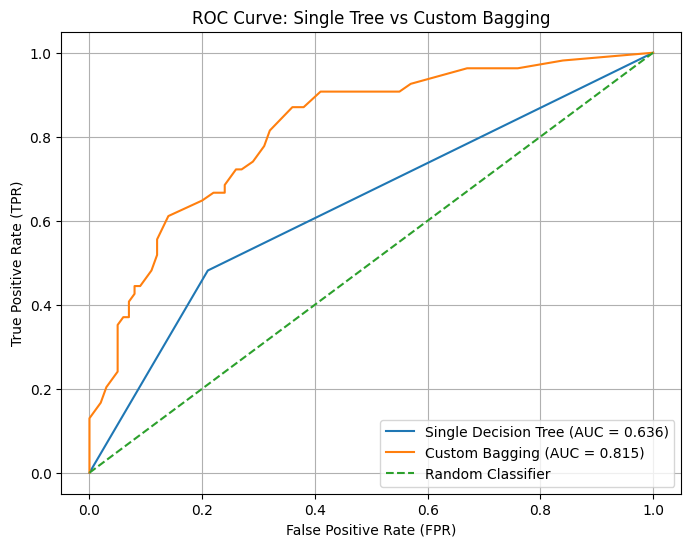

In [12]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# 1. Single Decision Tree Probability
# ------------------------------------------------

# Probability of class 1
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# ------------------------------------------------
# 2. Custom Bagging Probability
# ------------------------------------------------

# Store probability predictions of all trees
all_probabilities = []

for model in ensemble:
    # Get probability of class 1
    prob = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(prob)

# Convert to NumPy array
all_probabilities = np.array(all_probabilities)

# Average probability across all 50 trees
y_prob_bagging = np.mean(all_probabilities, axis=0)


# ------------------------------------------------
# 3. Calculate ROC Curve
# ------------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# ------------------------------------------------
# 4. Calculate AUC
# ------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# ------------------------------------------------
# 5. Print AUC
# ------------------------------------------------

print("AUC - Single Decision Tree:", auc_single)
print("AUC - Custom Bagging:", auc_bagging)


# ------------------------------------------------
# 6. Plot ROC Curves
# ------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f'Single Decision Tree (AUC = {auc_single:.3f})'
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f'Custom Bagging (AUC = {auc_bagging:.3f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Single Tree vs Custom Bagging')

plt.legend()
plt.grid(True)

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [13]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------------------------------
# 1. Create Scikit-Learn BaggingClassifier
# ------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)


# ------------------------------------------------
# 2. Train the BaggingClassifier
# ------------------------------------------------

bagging_model.fit(X_train, y_train)


# ------------------------------------------------
# 3. Predict on test data
# ------------------------------------------------

y_pred_sklearn = bagging_model.predict(X_test)


# ------------------------------------------------
# 4. Calculate Accuracy
# ------------------------------------------------

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------------
# 5. Calculate Confusion Matrix
# ------------------------------------------------

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# ------------------------------------------------
# 6. Display Scikit-Learn Results
# ------------------------------------------------

print("========== Scikit-Learn BaggingClassifier ==========")

print("\nTest Accuracy:")
print(accuracy_sklearn)

print("\nConfusion Matrix:")
print(cm_sklearn)


# ------------------------------------------------
# 7. Custom Bagging Results
# ------------------------------------------------

accuracy_custom = accuracy_score(
    y_test,
    y_pred_bagging
)

cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("\n========== Custom Bagging ==========")

print("\nTest Accuracy:")
print(accuracy_custom)

print("\nConfusion Matrix:")
print(cm_custom)


# ------------------------------------------------
# 8. Compare both implementations
# ------------------------------------------------

print("\n========== Comparison ==========")

print("Custom Bagging Accuracy     :", accuracy_custom)
print("Scikit-Learn Bagging Accuracy:", accuracy_sklearn)

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Confusion Matrix:")
print(cm_sklearn)

========== Scikit-Learn BaggingClassifier ==========

Test Accuracy:
0.7337662337662337

Confusion Matrix:
[[85 15]
 [26 28]]

========== Custom Bagging ==========

Test Accuracy:
0.7532467532467533

Confusion Matrix:
[[88 12]
 [26 28]]

========== Comparison ==========
Custom Bagging Accuracy     : 0.7532467532467533
Scikit-Learn Bagging Accuracy: 0.7337662337662337

Custom Bagging Confusion Matrix:
[[88 12]
 [26 28]]

Scikit-Learn Confusion Matrix:
[[85 15]
 [26 28]]


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?